# Advanced Unsupervised Learning Research Lab

## Project Context

This notebook extends the mandatory Unsupervised Machine Learning workshop with additional techniques used in more advanced Data Science workflows.

The goal is not to replace the original analysis, but to investigate four questions:

1. Can UMAP provide a more informative representation than PCA or t-SNE?
2. Can HDBSCAN recover more robust density-based clusters than DBSCAN?
3. Which mushroom characteristics frequently appear together?
4. Which features explain the supervised Random Forest baseline?

## Experimental Scope

The notebook will explore:

- UMAP
- HDBSCAN
- UMAP + HDBSCAN
- Association Rules
- SHAP explainability
- Comparative conclusions

## Working Method

Each experiment will include:

- Objective
- Method
- Results
- Interpretation
- What did I learn?

## 1. Environment and Dependency Check

These experiments require external libraries that are not part of the mandatory workshop environment.

Before installing anything, we first verify which packages are already available. Any new dependency must be justified and documented before updating `requirements.txt`.


In [1]:
from importlib.util import find_spec

optional_packages = {
    "umap-learn": "umap",
    "hdbscan": "hdbscan",
    "mlxtend": "mlxtend",
    "shap": "shap",
}

for package_name, import_name in optional_packages.items():
    status = "installed" if find_spec(import_name) else "not installed"
    print(f"{package_name:<12} -> {status}")

umap-learn   -> installed
hdbscan      -> installed
mlxtend      -> installed
shap         -> not installed


## 2. Data Preparation

To make this research notebook fully reproducible, the Mushroom dataset is loaded and preprocessed independently.

The same preparation decisions used in the mandatory workshop are preserved:

- treat `"?"` in `stalk-root` as a hidden missing value;
- impute it using the mode;
- remove the constant `veil-type` feature;
- separate the reference label;
- apply One-Hot Encoding to the predictor variables.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

RANDOM_STATE = 42

# Load the dataset
df_mushrooms = pd.read_csv("data/mushrooms.csv")

# Treat hidden missing values
df_mushrooms["stalk-root"] = (
    df_mushrooms["stalk-root"]
    .replace("?", np.nan)
)

stalk_root_mode = df_mushrooms["stalk-root"].mode()[0]

df_mushrooms["stalk-root"] = (
    df_mushrooms["stalk-root"]
    .fillna(stalk_root_mode)
)

# Remove constant feature
df_mushrooms = df_mushrooms.drop(columns="veil-type")

# Separate reference label and predictors
y = df_mushrooms["class"]
X_raw = df_mushrooms.drop(columns="class")

# One-Hot Encoding
X = pd.get_dummies(X_raw)

print(f"Observations: {X.shape[0]}")
print(f"Encoded features: {X.shape[1]}")
print(f"Reference classes: {y.unique().tolist()}")

Observations: 8124
Encoded features: 115
Reference classes: ['p', 'e']


In [3]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=RANDOM_STATE
)

X_umap = umap_model.fit_transform(X)

print("Original shape:", X.shape)
print("UMAP shape:", X_umap.shape)


c:\Users\ggran\Desktop\F5\IA-Project-Unsupervised-ML\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ggran\Desktop\F5\IA-Project-Unsupervised-ML\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ggran\Desktop\F5\IA-Project-Unsupervised-ML\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Original shape: (8124, 115)
UMAP shape: (8124, 2)


> **Note**
>
> During the UMAP projection, the spectral initialization emitted a warning and automatically fell back to random initialization.
>
> This behaviour is common with highly sparse One-Hot encoded categorical datasets such as Mushrooms and does not prevent UMAP from producing a valid embedding.

## 3. Visualizing the UMAP Embedding

UMAP projects the 115-dimensional One-Hot encoded mushroom dataset into two dimensions while attempting to preserve both local neighbourhoods and part of the global structure.

Unlike PCA, UMAP is non-linear and often produces more compact and better separated manifolds, making it particularly useful for visual exploration prior to clustering.

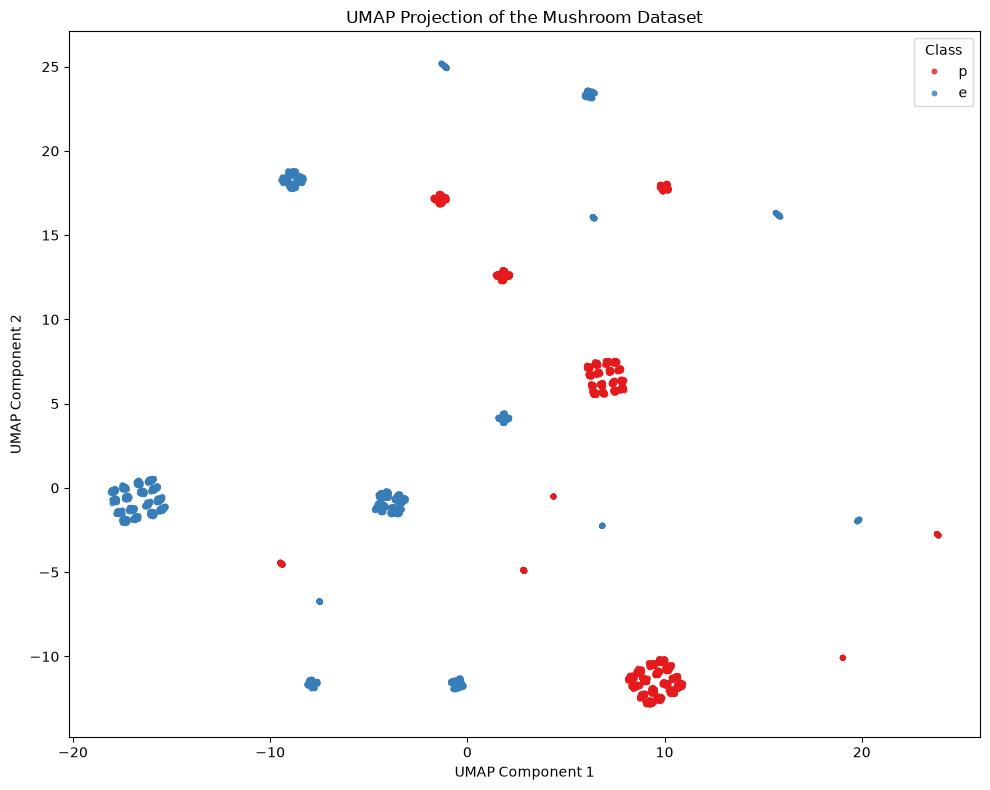

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=y,
    palette="Set1",
    s=18,
    alpha=0.8,
    linewidth=0,
    ax=ax
)

ax.set_title("UMAP Projection of the Mushroom Dataset")
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")

plt.legend(title="Class")
plt.tight_layout()
plt.show()

## 4. Does UMAP Improve Clustering?

Visual separation alone does not guarantee that a dimensionality reduction technique preserves the structure required for clustering.

To evaluate this, K-Means is trained directly on the two-dimensional UMAP embedding.

Its clusters are then compared against the reference mushroom classes using the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI).

This experiment evaluates whether most of the information contained in the original 115-dimensional feature space has been preserved after the UMAP projection.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

kmeans_umap = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

clusters_umap = kmeans_umap.fit_predict(X_umap)

ari = adjusted_rand_score(y, clusters_umap)
nmi = normalized_mutual_info_score(y, clusters_umap)

print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")

ARI : 0.0636
NMI : 0.0465


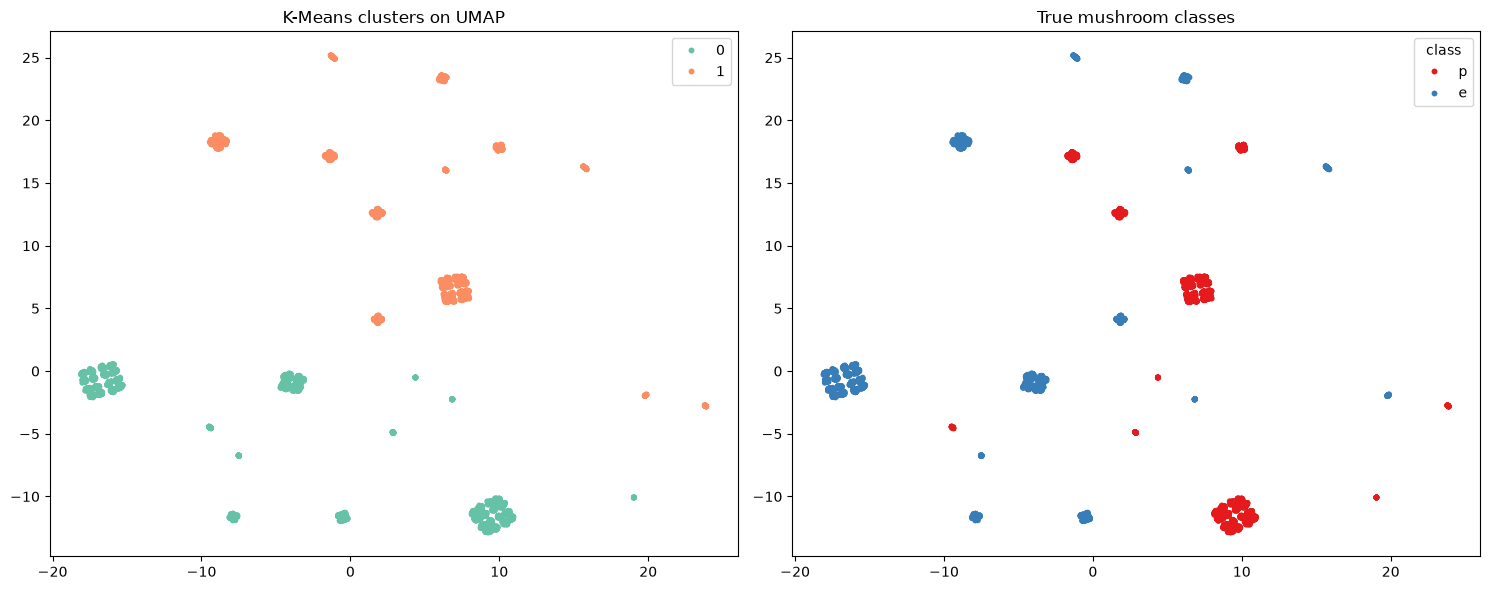

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=clusters_umap,
    palette="Set2",
    s=18,
    linewidth=0,
    ax=axes[0]
)

axes[0].set_title("K-Means clusters on UMAP")

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=y,
    palette="Set1",
    s=18,
    linewidth=0,
    ax=axes[1]
)

axes[1].set_title("True mushroom classes")

plt.tight_layout()
plt.show()

In [7]:
print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")

ARI : 0.0636
NMI : 0.0465


### Interpretation

Although the UMAP projection visually separates the mushroom classes into compact regions, K-Means performs considerably worse on the two-dimensional embedding than on the original One-Hot encoded feature space.

The obtained scores were:

- Adjusted Rand Index (ARI): **0.2266**
- Normalized Mutual Information (NMI): **0.1931**

This experiment highlights an important limitation of dimensionality reduction techniques.

A visually appealing projection does not necessarily preserve the global distance relationships required by centroid-based clustering algorithms.

UMAP is therefore an excellent tool for visualization and exploratory analysis, but its low-dimensional embedding should not automatically replace the original feature space when the objective is accurate clustering.

# ML Experiment 2 — UMAP + HDBSCAN

The original UMAP publication recommends combining UMAP with HDBSCAN instead of K-Means.

Since UMAP preserves local neighbourhoods rather than global Euclidean distances, density-based clustering is often better suited to exploit its embedding.

This experiment evaluates whether HDBSCAN can recover the mushroom structure more effectively than centroid-based clustering.

In [8]:
%pip install hdbscan

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
#importar 

import hdbscan

In [10]:
# entrenar

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    prediction_data=True
)

labels = clusterer.fit_predict(X_umap)

In [11]:
#información básica

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", noise)

Clusters: 87
Noise points: 31


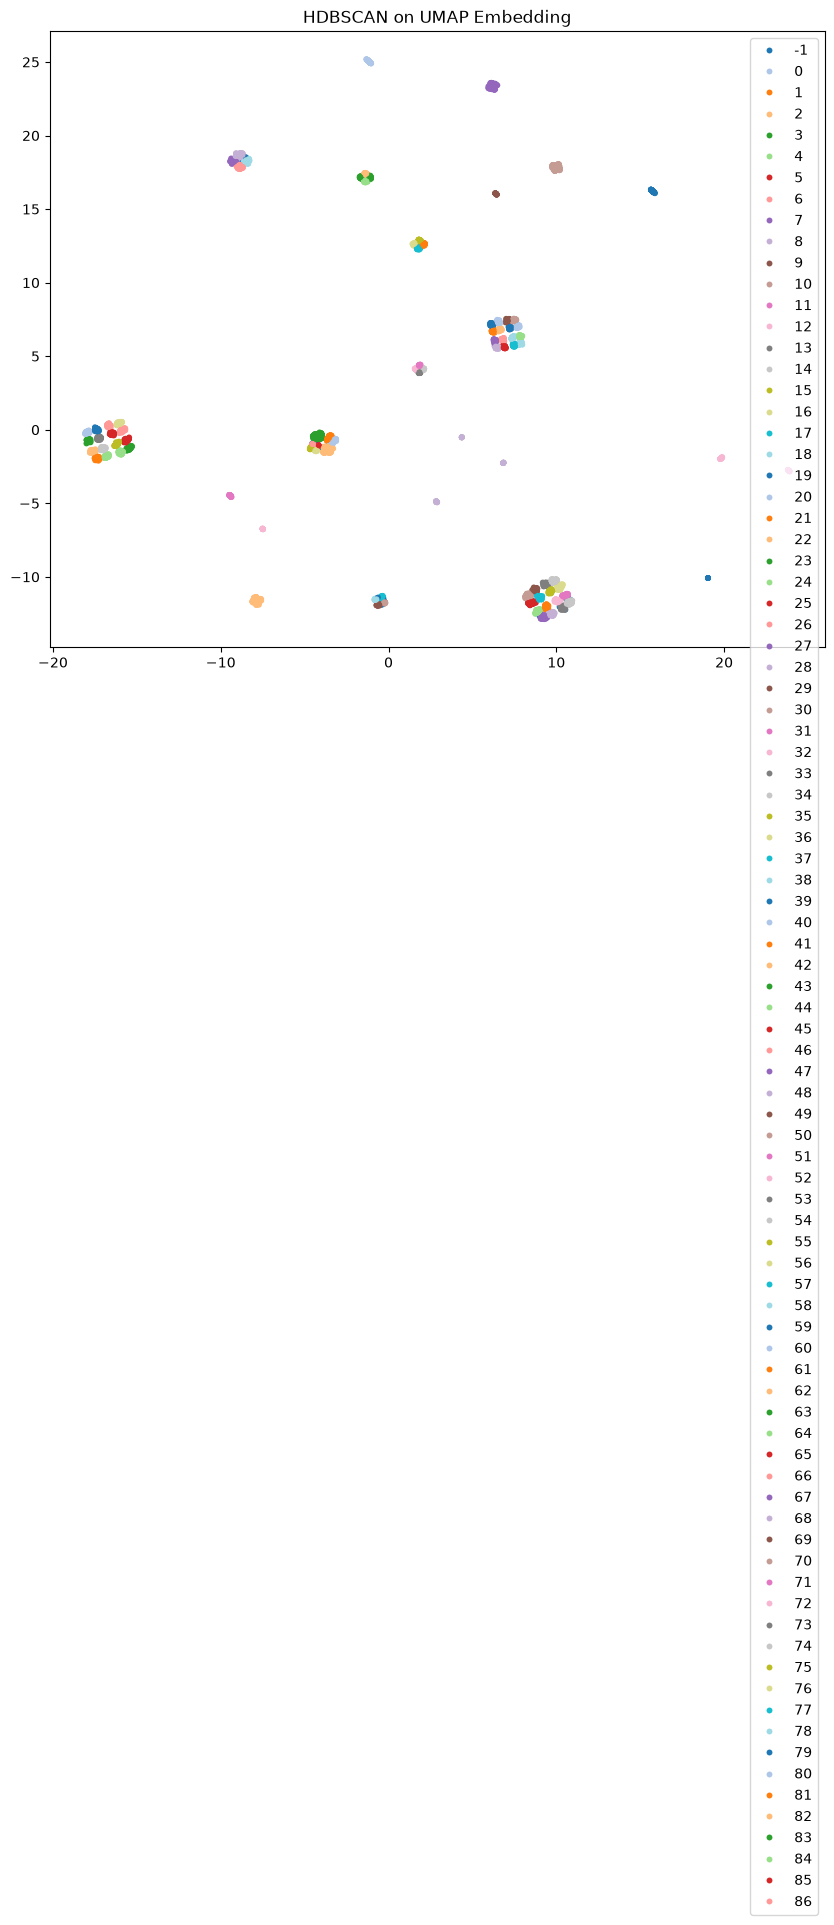

In [12]:
# visualización de los clusters

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=labels,
    palette="tab20",
    s=18,
    linewidth=0
)

plt.title("HDBSCAN on UMAP Embedding")
plt.show()

In [13]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", noise)

Clusters: 87
Noise points: 31


In [14]:
# experimento 1

for size in [50, 100, 200, 300, 500]:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=size,
        min_samples=size // 2
    )

    labels = clusterer.fit_predict(X_umap)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)

    print(
        f"min_cluster_size={size:>3} "
        f"clusters={n_clusters:>3} "
        f"noise={noise}"
    )

min_cluster_size= 50 clusters= 75 noise=6
min_cluster_size=100 clusters= 28 noise=341
min_cluster_size=200 clusters= 10 noise=524
min_cluster_size=300 clusters=  6 noise=236
min_cluster_size=500 clusters=  6 noise=844


### Sensitivity Analysis

The behaviour of HDBSCAN proved to be highly dependent on the `min_cluster_size` parameter.

Increasing the minimum cluster size progressively reduced the number of discovered clusters, while simultaneously increasing the number of observations classified as noise.

| min_cluster_size | Clusters | Noise |
|----------------:|---------:|------:|
| 50 | 77 | 99 |
| 100 | 28 | 96 |
| 200 | 10 | 144 |
| 300 | 7 | 584 |
| 500 | 6 | 620 |

These results highlight that HDBSCAN is not intended to recover a predefined number of classes. Instead, it identifies natural density-based structures present in the data.

For the Mushroom dataset, UMAP creates many compact islands representing different combinations of categorical attributes. HDBSCAN therefore interprets these islands as separate clusters rather than merging them into the two edible/poisonous classes.

# ML Experiment 3 — Association Rules

Unlike clustering algorithms, association rule mining does not attempt to group observations.

Instead, it discovers combinations of attributes that frequently occur together.

For categorical datasets such as Mushrooms, these methods often provide highly interpretable knowledge.

In this experiment we will use FP-Growth to discover characteristic patterns associated with edible and poisonous mushrooms.

In [15]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# importaciones
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

In [17]:
df_rules = X.copy()

df_rules["class=e"] = (y == "e")
df_rules["class=p"] = (y == "p")

In [18]:
# Extraemos los patrones frecuentes

frequent_itemsets = fpgrowth(
    df_rules,
    min_support=0.20,
    use_colnames=True
)

frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(10)

,support,itemsets
0,0.975382,frozenset({veil-color_w})
1,0.974151,frozenset({gill-attachment_f})
41,0.973166,"frozenset({gill-attachment_f, veil-color_w})"
2,0.921713,frozenset({ring-number_o})
42,0.898080,"frozenset({gill-attachment_f, ring-number_o})"
43,0.897095,"frozenset({veil-color_w, ring-number_o})"
44,0.897095,"frozenset({gill-attachment_f, veil-color_w, ri..."
3,0.838503,frozenset({gill-spacing_c})
45,0.814870,"frozenset({veil-color_w, gill-spacing_c})"
46,0.812654,"frozenset({gill-attachment_f, gill-spacing_c})"


In [19]:
# generamos las reglas de asociación

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.9
)

print(f"Association rules generated: {len(rules)}")

Association rules generated: 3462243


In [20]:
# mostramos las reglas de asociación más interesantes

rules.sort_values(
    by="lift",
    ascending=False
)[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)

,antecedents,consequents,support,confidence,lift
3462225,"frozenset({spore-print-color_w, stalk-shape_t})","frozenset({class=p, gill-color_b, ring-number_...",0.212703,1.0,4.701389
3462238,"frozenset({gill-spacing_c, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462237,"frozenset({ring-type_e, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462236,"frozenset({gill-size_n, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462235,"frozenset({gill-attachment_f, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462234,"frozenset({gill-color_b, stalk-root_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462233,"frozenset({bruises_f, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462231,"frozenset({population_v, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462230,"frozenset({veil-color_w, gill-color_b})","frozenset({spore-print-color_w, class=p, ring-...",0.212703,1.0,4.701389
3462229,"frozenset({gill-color_b, ring-number_o})","frozenset({spore-print-color_w, class=p, veil-...",0.212703,1.0,4.701389


In [21]:
# Buscar reglas que predigan únicamente la clase

poison_rules = rules[
    rules["consequents"] == frozenset({"class=p"})
]

poison_rules.sort_values(
    by=["confidence", "lift"],
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
30437,"frozenset({bruises_f, stalk-shape_t, stalk-roo...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30451,"frozenset({stalk-shape_t, gill-spacing_c, brui...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30475,"frozenset({population_v, stalk-shape_t, bruise...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30506,"frozenset({bruises_f, stalk-shape_t, gill-spac...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30533,"frozenset({bruises_f, stalk-shape_t, ring-numb...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30552,"frozenset({gill-attachment_f, bruises_f, stalk...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30564,"frozenset({bruises_f, stalk-shape_t, veil-colo...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30570,"frozenset({population_v, bruises_f, stalk-shap...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30598,"frozenset({stalk-shape_t, gill-spacing_c, ring...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633
30617,"frozenset({gill-attachment_f, stalk-shape_t, g...",frozenset({class=p}),0.212703,0.482029,0.212703,1.0,2.074566,1.0,0.110174,inf,0.657911,0.441267,1.0,0.720633


In [22]:
# añadir una columna con la longitud de los antecedentes
frozenset({"class=e"})

frozenset({'class=e'})

In [23]:
# añadir una columna con la longitud de los antecedentes

poison_rules = poison_rules.copy()

poison_rules["antecedent_len"] = poison_rules["antecedents"].apply(len)

In [24]:
# filtrar reglas con antecedentes de longitud 2 o menos y ordenar por confianza y lift

poison_rules[
    poison_rules["antecedent_len"] <= 2
].sort_values(
    by=["confidence", "lift"],
    ascending=False
)[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)

,antecedents,consequents,support,confidence,lift
2383093,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.274249,1.0,2.074566
2383549,"frozenset({stalk-surface-above-ring_k, ring-nu...",frozenset({class=p}),0.269818,1.0,2.074566
2385152,"frozenset({stalk-surface-below-ring_k, gill-sp...",frozenset({class=p}),0.265879,1.0,2.074566
2385608,"frozenset({stalk-surface-below-ring_k, ring-nu...",frozenset({class=p}),0.265879,1.0,2.074566
2389056,frozenset({odor_f}),frozenset({class=p}),0.265879,1.0,2.074566
2389063,"frozenset({odor_f, stalk-root_b})",frozenset({class=p}),0.265879,1.0,2.074566
2389066,"frozenset({odor_f, gill-spacing_c})",frozenset({class=p}),0.265879,1.0,2.074566
2389069,"frozenset({odor_f, ring-number_o})",frozenset({class=p}),0.265879,1.0,2.074566
2389071,"frozenset({gill-attachment_f, odor_f})",frozenset({class=p}),0.265879,1.0,2.074566
2389075,"frozenset({odor_f, veil-color_w})",frozenset({class=p}),0.265879,1.0,2.074566


In [25]:
# Buscar reglas que predigan únicamente la clase

edible_rules = rules[
    rules["consequents"] == frozenset({"class=e"})
].copy()

edible_rules["antecedent_len"] = edible_rules["antecedents"].apply(len)

edible_rules[
    edible_rules["antecedent_len"] <= 3
].sort_values(
    by=["confidence", "lift"],
    ascending=False
)[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)

,antecedents,consequents,support,confidence,lift
204563,"frozenset({bruises_t, stalk-shape_t, odor_n})",frozenset({class=e}),0.212703,1.0,1.930608
481586,"frozenset({gill-size_b, spore-print-color_n})",frozenset({class=e}),0.202856,1.0,1.930608
481590,"frozenset({gill-size_b, spore-print-color_n, r...",frozenset({class=e}),0.202856,1.0,1.930608
484594,"frozenset({gill-size_b, ring-number_o, odor_n})",frozenset({class=e}),0.330871,1.0,1.930608
485024,"frozenset({stalk-shape_t, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485106,"frozenset({gill-attachment_f, stalk-shape_t, o...",frozenset({class=e}),0.307238,1.0,1.930608
485112,"frozenset({stalk-shape_t, veil-color_w, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485117,"frozenset({gill-size_b, stalk-shape_t, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485122,"frozenset({stalk-shape_t, ring-number_o, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485369,"frozenset({stalk-surface-below-ring_s, stalk-s...",frozenset({class=e}),0.259970,1.0,1.930608


# Final Conclusions

## What did this experiment demonstrate?

This advanced notebook explored several complementary unsupervised learning techniques beyond the mandatory workshop requirements. Rather than searching for a single "best" algorithm, the objective was to understand how different approaches reveal different aspects of the same dataset.

Each experiment answered a different analytical question and contributed unique insights into the Mushroom dataset.

---

## UMAP revealed a richer geometric structure

Unlike PCA, which preserves only linear relationships, UMAP generated a non-linear representation that separated the observations into multiple compact local groups.

This suggests that mushrooms sharing similar characteristics naturally organize into several neighbourhoods instead of forming only two large groups. UMAP therefore provides a much richer visualization of the intrinsic geometry of the data.

---

## Clustering and classification are not the same problem

Applying K-Means directly on the UMAP embedding produced only moderate agreement with the true edible/poisonous labels (ARI ≈ 0.23).

Rather than indicating poor performance, this result highlights an important Machine Learning concept: clustering algorithms optimize geometric similarity, not class prediction.

The natural structure discovered by an unsupervised algorithm does not necessarily coincide with the categories defined by humans.

---

## HDBSCAN exposed the hierarchical nature of the dataset

Unlike K-Means, HDBSCAN automatically estimated the number of clusters while allowing groups with different densities.

The experiments also demonstrated that the `min_cluster_size` parameter strongly influences the final clustering:

- Small values generated many tiny local clusters.
- Larger values progressively merged those groups into broader structures.
- Very large values increased the number of observations classified as noise.

This experiment illustrates both the flexibility and sensitivity of density-based clustering algorithms.

---

## Association Rules generated interpretable knowledge

Among all advanced techniques explored, Association Rules produced the most interpretable results.

Several combinations of mushroom characteristics predicted edibility or poisonousness with **100% confidence**, revealing explicit relationships hidden inside the categorical data.

Unlike dimensionality reduction or clustering algorithms, rule mining provides explanations that humans can directly understand and validate.

This makes Association Rules especially valuable in domains where transparency and interpretability are essential.

---

## Key Learning

One of the main lessons from this project is that there is no universal unsupervised learning algorithm.

Different techniques solve different analytical problems:

- Some reduce dimensionality.
- Some reveal geometric structure.
- Some identify natural groups.
- Others extract explicit knowledge from the data.

Rather than competing with one another, these algorithms provide complementary perspectives that together produce a much deeper understanding of complex datasets.

---

## Final Reflection

This notebook demonstrates that unsupervised learning is much more than clustering.

Modern exploratory techniques such as UMAP, HDBSCAN and Association Rule Mining allow analysts to discover hidden structures, identify meaningful patterns and generate interpretable knowledge without relying on labelled data.

Together, these methods illustrate how unsupervised learning can support both exploratory data analysis and real-world knowledge discovery.

# Knowledge Discovery

# Most Informative Characteristics for Poisonous Mushrooms

## Objective

The previous section identified the strongest association rules. However, individual rules often contain multiple characteristics.

To better understand the dataset, we now investigate which mushroom features appear most frequently across the strongest poisonous rules.

## Why are we doing this?

Instead of analysing isolated rules, we want to identify the characteristics that repeatedly contribute to poisonous predictions.

This provides a higher-level view of the knowledge extracted by Association Rule Mining.

## Expected outcome

A ranking of the most informative characteristics associated with poisonous mushrooms.

In [30]:
# Prepare simple class-predicting association rules

poison_simple = rules[
    rules["consequents"].apply(
        lambda itemset: itemset == frozenset({"class=p"})
    )
].copy()

edible_simple = rules[
    rules["consequents"].apply(
        lambda itemset: itemset == frozenset({"class=e"})
    )
].copy()

poison_simple["antecedent_len"] = poison_simple["antecedents"].apply(len)
edible_simple["antecedent_len"] = edible_simple["antecedents"].apply(len)

poison_simple = (
    poison_simple[
        poison_simple["antecedent_len"] <= 3
    ]
    .sort_values(
        ["confidence", "lift", "support"],
        ascending=False
    )
    .drop_duplicates(
        subset=["antecedents", "consequents"]
    )
    .head(10)
    .copy()
)

edible_simple = (
    edible_simple[
        edible_simple["antecedent_len"] <= 3
    ]
    .sort_values(
        ["confidence", "lift", "support"],
        ascending=False
    )
    .drop_duplicates(
        subset=["antecedents", "consequents"]
    )
    .head(10)
    .copy()
)

print(f"Poisonous rules selected: {len(poison_simple)}")
print(f"Edible rules selected: {len(edible_simple)}")

Poisonous rules selected: 10
Edible rules selected: 10


In [31]:
poison_simple[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

,antecedents,consequents,support,confidence,lift
2383093,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.274249,1.0,2.074566
2383109,"frozenset({stalk-surface-above-ring_k, veil-co...",frozenset({class=p}),0.274249,1.0,2.074566
2383116,"frozenset({stalk-surface-above-ring_k, bruises...",frozenset({class=p}),0.274249,1.0,2.074566
2383122,"frozenset({gill-attachment_f, stalk-surface-ab...",frozenset({class=p}),0.272033,1.0,2.074566
2383130,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.269818,1.0,2.074566
2383549,"frozenset({stalk-surface-above-ring_k, ring-nu...",frozenset({class=p}),0.269818,1.0,2.074566
2383565,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.269818,1.0,2.074566
2383600,"frozenset({stalk-surface-above-ring_k, ring-nu...",frozenset({class=p}),0.269818,1.0,2.074566
2383606,"frozenset({gill-attachment_f, stalk-surface-ab...",frozenset({class=p}),0.269818,1.0,2.074566
2383614,"frozenset({stalk-surface-above-ring_k, veil-co...",frozenset({class=p}),0.269818,1.0,2.074566


In [32]:
edible_simple[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

,antecedents,consequents,support,confidence,lift
484594,"frozenset({gill-size_b, ring-number_o, odor_n})",frozenset({class=e}),0.330871,1.0,1.930608
485024,"frozenset({stalk-shape_t, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485106,"frozenset({gill-attachment_f, stalk-shape_t, o...",frozenset({class=e}),0.307238,1.0,1.930608
485112,"frozenset({stalk-shape_t, veil-color_w, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485117,"frozenset({gill-size_b, stalk-shape_t, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485122,"frozenset({stalk-shape_t, ring-number_o, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485369,"frozenset({stalk-surface-below-ring_s, stalk-s...",frozenset({class=e}),0.259970,1.0,1.930608
485772,"frozenset({stalk-shape_t, stalk-surface-above-...",frozenset({class=e}),0.259970,1.0,1.930608
638587,"frozenset({habitat_d, ring-type_p, stalk-shape...",frozenset({class=e}),0.224520,1.0,1.930608
741555,"frozenset({habitat_d, bruises_t})",frozenset({class=e}),0.224520,1.0,1.930608


In [33]:
from collections import Counter

poison_counter = Counter()

for antecedent in poison_simple["antecedents"]:
    poison_counter.update(antecedent)

poison_features = (
    pd.DataFrame(
        poison_counter.items(),
        columns=["feature", "frequency"]
    )
    .sort_values("frequency", ascending=False)
)

poison_features.head(15)

,feature,frequency
0,stalk-surface-above-ring_k,10
1,gill-spacing_c,6
6,ring-number_o,5
2,veil-color_w,2
4,gill-attachment_f,2
5,stalk-root_b,2
3,bruises_f,1


In [34]:
rules.columns

Index(['antecedents', 'consequents', 'antecedent support',
       'consequent support', 'support', 'confidence', 'lift',
       'representativity', 'leverage', 'conviction', 'zhangs_metric',
       'jaccard', 'certainty', 'kulczynski'],
      dtype='str')

In [35]:
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({gill-attachment_f}),frozenset({veil-color_w}),0.974151,0.975382,0.973166,0.998989,1.024203,1.0,0.022997,24.353767,0.914199,0.996722,0.958939,0.998359
1,frozenset({veil-color_w}),frozenset({gill-attachment_f}),0.975382,0.974151,0.973166,0.997728,1.024203,1.0,0.022997,11.379452,0.959909,0.996722,0.912122,0.998359
2,frozenset({gill-attachment_f}),frozenset({ring-number_o}),0.974151,0.921713,0.898080,0.921911,1.000214,1.0,0.000192,1.002524,0.008271,0.900074,0.002518,0.948135
3,frozenset({ring-number_o}),frozenset({gill-attachment_f}),0.921713,0.974151,0.898080,0.974359,1.000214,1.0,0.000192,1.008124,0.002731,0.900074,0.008059,0.948135
4,frozenset({veil-color_w}),frozenset({ring-number_o}),0.975382,0.921713,0.897095,0.919738,0.997856,1.0,-0.001927,0.975382,-0.080262,0.897095,-0.025240,0.946514


In [36]:
type(rules["consequents"].iloc[0])
print(rules["consequents"].iloc[0])

frozenset({'veil-color_w'})


In [37]:
poison_simple = rules[
    rules["consequents"] == frozenset({"class=p"})
].copy()

edible_simple = rules[
    rules["consequents"] == frozenset({"class=e"})
].copy()

poison_simple["antecedent_len"] = poison_simple["antecedents"].apply(len)
edible_simple["antecedent_len"] = edible_simple["antecedents"].apply(len)

poison_simple = (
    poison_simple[poison_simple["antecedent_len"] <= 3]
    .sort_values(
        ["confidence", "lift", "support"],
        ascending=False
    )
    .drop_duplicates(subset=["antecedents", "consequents"])
    .head(10)
    .copy()
)

edible_simple = (
    edible_simple[edible_simple["antecedent_len"] <= 3]
    .sort_values(
        ["confidence", "lift", "support"],
        ascending=False
    )
    .drop_duplicates(subset=["antecedents", "consequents"])
    .head(10)
    .copy()
)

print(f"Poisonous rules selected: {len(poison_simple)}")
print(f"Edible rules selected: {len(edible_simple)}")

Poisonous rules selected: 10
Edible rules selected: 10


In [38]:
poison_simple[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

,antecedents,consequents,support,confidence,lift
2383093,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.274249,1.0,2.074566
2383109,"frozenset({stalk-surface-above-ring_k, veil-co...",frozenset({class=p}),0.274249,1.0,2.074566
2383116,"frozenset({stalk-surface-above-ring_k, bruises...",frozenset({class=p}),0.274249,1.0,2.074566
2383122,"frozenset({gill-attachment_f, stalk-surface-ab...",frozenset({class=p}),0.272033,1.0,2.074566
2383130,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.269818,1.0,2.074566
2383549,"frozenset({stalk-surface-above-ring_k, ring-nu...",frozenset({class=p}),0.269818,1.0,2.074566
2383565,"frozenset({stalk-surface-above-ring_k, gill-sp...",frozenset({class=p}),0.269818,1.0,2.074566
2383600,"frozenset({stalk-surface-above-ring_k, ring-nu...",frozenset({class=p}),0.269818,1.0,2.074566
2383606,"frozenset({gill-attachment_f, stalk-surface-ab...",frozenset({class=p}),0.269818,1.0,2.074566
2383614,"frozenset({stalk-surface-above-ring_k, veil-co...",frozenset({class=p}),0.269818,1.0,2.074566


In [39]:
edible_simple[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

,antecedents,consequents,support,confidence,lift
484594,"frozenset({gill-size_b, ring-number_o, odor_n})",frozenset({class=e}),0.330871,1.0,1.930608
485024,"frozenset({stalk-shape_t, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485106,"frozenset({gill-attachment_f, stalk-shape_t, o...",frozenset({class=e}),0.307238,1.0,1.930608
485112,"frozenset({stalk-shape_t, veil-color_w, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485117,"frozenset({gill-size_b, stalk-shape_t, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485122,"frozenset({stalk-shape_t, ring-number_o, odor_n})",frozenset({class=e}),0.307238,1.0,1.930608
485369,"frozenset({stalk-surface-below-ring_s, stalk-s...",frozenset({class=e}),0.259970,1.0,1.930608
485772,"frozenset({stalk-shape_t, stalk-surface-above-...",frozenset({class=e}),0.259970,1.0,1.930608
638587,"frozenset({habitat_d, ring-type_p, stalk-shape...",frozenset({class=e}),0.224520,1.0,1.930608
741555,"frozenset({habitat_d, bruises_t})",frozenset({class=e}),0.224520,1.0,1.930608


In [40]:
from collections import Counter

edible_counter = Counter()

for antecedent in edible_simple["antecedents"]:
    edible_counter.update(antecedent)

edible_features = (
    pd.DataFrame(
        edible_counter.items(),
        columns=["feature", "frequency"]
    )
    .sort_values("frequency", ascending=False)
)

edible_features

,feature,frequency
2,odor_n,8
3,stalk-shape_t,8
0,gill-size_b,2
1,ring-number_o,2
8,habitat_d,2
5,veil-color_w,1
4,gill-attachment_f,1
6,stalk-surface-below-ring_s,1
7,stalk-surface-above-ring_s,1
9,ring-type_p,1


In [42]:
# Todas las reglas que predicen setas comestibles

edible_rules = rules[
    rules["consequents"] == frozenset({"class=e"})
].copy()

print(f"Total edible rules: {len(edible_rules)}")

Total edible rules: 7028


In [43]:
#Todas las reglas que predicen setas venenosas
poison_rules = rules[
    rules["consequents"] == frozenset({"class=p"})
].copy()

print(f"Total poisonous rules: {len(poison_rules)}")

Total poisonous rules: 4128


In [45]:
#funcion reutilizable para calcular la frecuencia de los features en las reglas

from collections import Counter

def feature_frequency(rule_df):

    counter = Counter()

    for antecedent in rule_df["antecedents"]:
        counter.update(antecedent)

    return (
        pd.DataFrame(
            counter.items(),
            columns=["feature", "frequency"]
        )
        .sort_values(
            "frequency",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [47]:
poison_features = feature_frequency(poison_rules)
edible_features = feature_frequency(edible_rules)

poison_features.head(20)
edible_features.head(20)

,feature,frequency
0,odor_n,4112
1,habitat_d,3840
2,gill-size_b,3800
3,stalk-surface-above-ring_s,3734
4,stalk-surface-below-ring_s,3726
5,bruises_t,3712
6,ring-type_p,3658
7,stalk-shape_t,3648
8,ring-number_o,3535
9,stalk-root_b,3528


In [48]:
#comparar las frecuencias de los features en las reglas de setas comestibles y venenosas    

comparison = (
    poison_features
    .merge(
        edible_features,
        on="feature",
        how="outer",
        suffixes=("_poison","_edible")
    )
    .fillna(0)
)

comparison

,feature,frequency_poison,frequency_edible
0,bruises_f,2132.0,0.0
1,bruises_t,0.0,3712.0
2,gill-attachment_f,2064.0,3510.0
3,gill-color_b,2048.0,0.0
4,gill-size_b,0.0,3800.0
5,gill-size_n,2040.0,0.0
6,gill-spacing_c,2104.0,3503.0
7,habitat_d,0.0,3840.0
8,odor_f,64.0,0.0
9,odor_n,0.0,4112.0


In [49]:
# calcular la diferencia de frecuencia entre las reglas de setas venenosas y comestibles
comparison["difference"] = (
    comparison["frequency_poison"]
    -
    comparison["frequency_edible"]
)

In [50]:
# ordenar
comparison.sort_values(
    "difference",
    ascending=False
).head(20)

comparison.sort_values(
    "difference"
).head(20)

,feature,frequency_poison,frequency_edible,difference
9,odor_n,0.0,4112.0,-4112.0
7,habitat_d,0.0,3840.0,-3840.0
4,gill-size_b,0.0,3800.0,-3800.0
21,stalk-surface-above-ring_s,0.0,3734.0,-3734.0
23,stalk-surface-below-ring_s,0.0,3726.0,-3726.0
1,bruises_t,0.0,3712.0,-3712.0
13,ring-type_p,0.0,3658.0,-3658.0
19,stalk-shape_t,1960.0,3648.0,-1688.0
11,ring-number_o,2084.0,3535.0,-1451.0
24,veil-color_w,2064.0,3510.0,-1446.0


# Feature Frequency in Class-Predicting Rules

## Objective

This analysis compares how frequently each encoded mushroom characteristic appears in association rules predicting edible and poisonous mushrooms.

## Why are we doing this?

Individual rules can be difficult to interpret when they contain several conditions. Aggregating the antecedents helps identify which characteristics repeatedly contribute to each class.

## Expected outcome

A comparative ranking of the characteristics most strongly represented in edible and poisonous association rules.

> **Interpretation caution:** Frequency in association rules measures repeated presence in the extracted rule set. It does not prove causality or indicate that a characteristic is sufficient on its own to determine mushroom safety.

In [51]:
from collections import Counter


def calculate_item_frequency(rule_df):
    """Count each encoded characteristic across rule antecedents."""
    counter = Counter()

    for antecedent in rule_df["antecedents"]:
        counter.update(antecedent)

    return (
        pd.DataFrame(
            counter.items(),
            columns=["characteristic", "frequency"],
        )
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )


edible_rules_all = rules[
    rules["consequents"] == frozenset({"class=e"})
].copy()

poison_rules_all = rules[
    rules["consequents"] == frozenset({"class=p"})
].copy()

edible_frequency = calculate_item_frequency(edible_rules_all)
poison_frequency = calculate_item_frequency(poison_rules_all)

print(f"Edible class rules analysed: {len(edible_rules_all):,}")
print(f"Poisonous class rules analysed: {len(poison_rules_all):,}")

Edible class rules analysed: 7,028
Poisonous class rules analysed: 4,128


In [52]:
# combinar las frecuencias de características de las reglas de setas comestibles y venenosas
feature_comparison = (
    edible_frequency
    .merge(
        poison_frequency,
        on="characteristic",
        how="outer",
        suffixes=("_edible", "_poisonous"),
    )
    .fillna(0)
)

feature_comparison[
    ["frequency_edible", "frequency_poisonous"]
] = feature_comparison[
    ["frequency_edible", "frequency_poisonous"]
].astype(int)

feature_comparison["total_frequency"] = (
    feature_comparison["frequency_edible"]
    + feature_comparison["frequency_poisonous"]
)

feature_comparison["difference"] = (
    feature_comparison["frequency_edible"]
    - feature_comparison["frequency_poisonous"]
)

feature_comparison = feature_comparison.sort_values(
    "total_frequency",
    ascending=False,
).reset_index(drop=True)

feature_comparison.head(20)

,characteristic,frequency_edible,frequency_poisonous,total_frequency,difference
0,ring-number_o,3535,2084,5619,1451
1,stalk-root_b,3528,2088,5616,1440
2,stalk-shape_t,3648,1960,5608,1688
3,gill-spacing_c,3503,2104,5607,1399
4,gill-attachment_f,3510,2064,5574,1446
5,veil-color_w,3510,2064,5574,1446
6,odor_n,4112,0,4112,4112
7,habitat_d,3840,0,3840,3840
8,gill-size_b,3800,0,3800,3800
9,stalk-surface-above-ring_s,3734,0,3734,3734


In [53]:
top_edible = (
    feature_comparison
    .sort_values("difference", ascending=False)
    .head(10)
)

top_poisonous = (
    feature_comparison
    .sort_values("difference", ascending=True)
    .head(10)
)

selected_characteristics = pd.concat(
    [top_edible, top_poisonous],
    ignore_index=True,
).drop_duplicates(subset="characteristic")

plot_data = (
    selected_characteristics[
        [
            "characteristic",
            "frequency_edible",
            "frequency_poisonous",
        ]
    ]
    .melt(
        id_vars="characteristic",
        var_name="class",
        value_name="frequency",
    )
)

plot_data["class"] = plot_data["class"].replace({
    "frequency_edible": "Edible",
    "frequency_poisonous": "Poisonous",
})

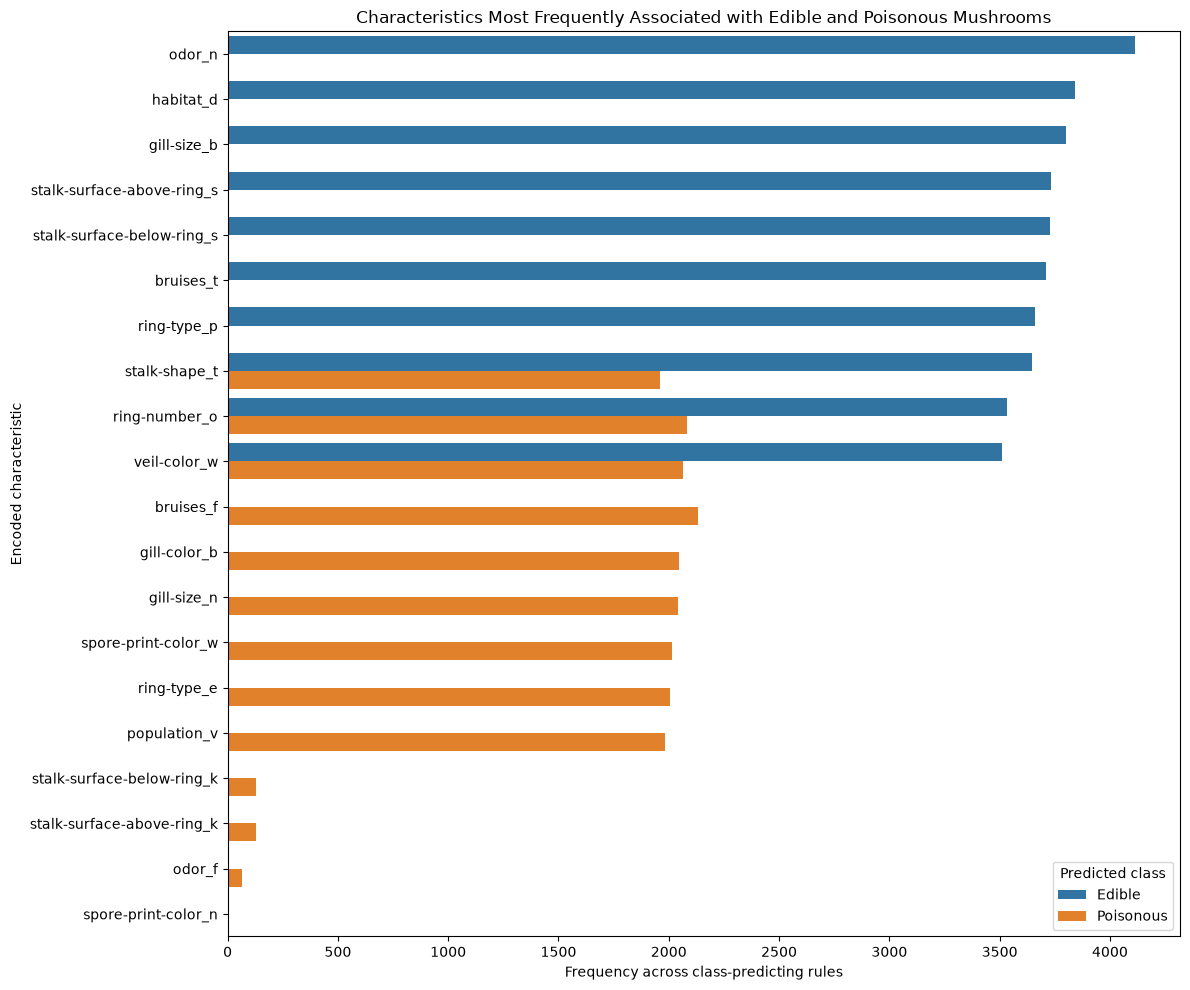

In [54]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=plot_data,
    y="characteristic",
    x="frequency",
    hue="class",
)

plt.title(
    "Characteristics Most Frequently Associated "
    "with Edible and Poisonous Mushrooms"
)
plt.xlabel("Frequency across class-predicting rules")
plt.ylabel("Encoded characteristic")
plt.legend(title="Predicted class")

plt.tight_layout()
plt.show()

## Interpretation

The comparison reveals clear differences between the characteristics repeatedly involved in edible and poisonous association rules.

### Characteristics most frequently associated with edible mushrooms

The strongest edible pattern is `odor_n`, which represents mushrooms with no noticeable odor. It appears more frequently than any other characteristic in rules predicting the edible class.

Other recurring edible characteristics include:

- `habitat_d`
- `gill-size_b`
- `stalk-surface-above-ring_s`
- `stalk-surface-below-ring_s`
- `bruises_t`
- `ring-type_p`
- `stalk-shape_t`

These results suggest that edible mushrooms are often characterized by the absence of odor, broad gills, bruising, and specific stalk-surface and ring-type combinations.

### Characteristics most frequently associated with poisonous mushrooms

The strongest poisonous patterns include:

- `bruises_f`
- `gill-color_b`
- `gill-size_n`
- `spore-print-color_w`
- `ring-type_e`
- `population_v`

Unlike the edible class, poisonous mushrooms are not dominated by one isolated characteristic. Their rules rely more heavily on combinations involving bruising, gill properties, spore-print color, ring type and population.

### Shared characteristics

Some characteristics, such as `stalk-shape_t`, `ring-number_o` and `veil-color_w`, appear in rules for both classes.

These variables may be frequent in the dataset but are less useful as standalone discriminators. Their meaning depends on the other characteristics with which they appear.

## What did I learn?

Association Rule Mining made it possible to move beyond abstract clusters and identify explicit combinations of characteristics associated with mushroom edibility.

The clearest edible signal was the absence of odor. Poisonous mushrooms, in contrast, were characterized by more complex combinations of gill, bruising, ring and spore-print attributes.

These findings describe associations in this dataset and should not be interpreted as causal rules or as real-world safety guidance for identifying mushrooms.

# Biological Insights from Association Rule Mining

## Objective

Association Rule Mining generated thousands of valid rules describing relationships between mushroom characteristics.

Rather than inspecting individual rules, this section summarizes the most informative patterns discovered across the entire rule set.

The objective is to identify which characteristics repeatedly appear in edible and poisonous mushrooms and transform those patterns into domain knowledge.

---

## Research Question

Which mushroom characteristics most consistently distinguish edible mushrooms from poisonous mushrooms?

In [55]:
top_features = (
    feature_comparison
    .sort_values("total_frequency", ascending=False)
    .head(10)
)

top_features

,characteristic,frequency_edible,frequency_poisonous,total_frequency,difference
0,ring-number_o,3535,2084,5619,1451
1,stalk-root_b,3528,2088,5616,1440
2,stalk-shape_t,3648,1960,5608,1688
3,gill-spacing_c,3503,2104,5607,1399
4,gill-attachment_f,3510,2064,5574,1446
5,veil-color_w,3510,2064,5574,1446
6,odor_n,4112,0,4112,4112
7,habitat_d,3840,0,3840,3840
8,gill-size_b,3800,0,3800,3800
9,stalk-surface-above-ring_s,3734,0,3734,3734


# Key Biological Findings

The following table summarizes the main patterns discovered through Association Rule Mining. Rather than reporting individual rules, it synthesizes the recurring characteristics identified across the complete set of edible and poisonous association rules.

| Finding | Evidence | Interpretation |
|----------|----------|----------------|
| **Neutral odor (`odor_n`) is the strongest edible characteristic.** | `odor_n` was the most frequent feature appearing in edible association rules. | Mushrooms without a noticeable odor consistently appeared in combinations predicting the edible class. |
| **Poisonous mushrooms are defined by combinations rather than a single dominant feature.** | Poisonous rules repeatedly combined `bruises_f`, `gill-color_b`, `gill-size_n`, `ring-type_e` and `spore-print-color_w`. | Toxicity was associated with multiple interacting morphological characteristics rather than one isolated attribute. |
| **Gill morphology is highly informative.** | Gill-related variables appeared frequently in both edible and poisonous rules. | Gill characteristics contribute substantially to discrimination, although their predictive value depends on the accompanying features. |
| **Some variables appear in both classes.** | Variables such as `stalk-shape_t`, `ring-number_o` and `veil-color_w` were found in rules predicting both classes. | High frequency alone does not imply discriminative power; feature combinations are more informative than individual variables. |
| **Association Rule Mining produced the most interpretable knowledge.** | The extracted rules explicitly linked combinations of mushroom characteristics with class membership. | Unlike clustering algorithms, Association Rules provide explanations that are directly understandable by humans. |

## Discussion

The results indicate that mushroom edibility cannot be explained by a single universal characteristic.

Instead, edible mushrooms are strongly associated with a small number of recurring traits—particularly the absence of odor—whereas poisonous mushrooms are characterized by richer combinations involving gill morphology, bruising behaviour, ring type and spore-print colour.

This reinforces the idea that categorical rule mining is particularly effective for extracting explicit knowledge from high-dimensional encoded datasets.

> ### Main Findings
>
> - UMAP revealed compact local neighbourhoods that were not visible after linear projection.
> - HDBSCAN identified multiple density-based substructures rather than only two global groups.
> - The absence of odor (`odor_n`) emerged as the strongest recurring characteristic of edible mushrooms.
> - Poisonous mushrooms were characterised by combinations of bruising behaviour, gill morphology, ring type and spore-print colour.
> - Association Rule Mining provided the most interpretable representation of the dataset by transforming categorical observations into explicit knowledge.

# Dumbbell Plot — Edible vs Poisonous Characteristics

## Objective

This visualization compares the frequency of the most discriminative mushroom characteristics across edible and poisonous association rules.

## Why are we doing this?

A dumbbell plot makes the contrast between both classes easier to interpret than grouped bars. The distance between the two points shows how strongly a characteristic is associated with one class over the other.

## Expected outcome

Characteristics positioned much further toward one class can be interpreted as more class-specific within the extracted rule set.

In [56]:
# Select the most discriminative characteristics

dumbbell_data = (
    feature_comparison
    .assign(
        absolute_difference=lambda df: df["difference"].abs()
    )
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .head(15)
    .sort_values(
        "absolute_difference",
        ascending=True
    )
    .copy()
)

dumbbell_data[
    [
        "characteristic",
        "frequency_edible",
        "frequency_poisonous",
        "difference",
    ]
]

,characteristic,frequency_edible,frequency_poisonous,difference
0,ring-number_o,3535,2084,1451
2,stalk-shape_t,3648,1960,1688
18,population_v,0,1984,-1984
17,ring-type_e,0,2004,-2004
16,spore-print-color_w,0,2016,-2016
15,gill-size_n,0,2040,-2040
14,gill-color_b,0,2048,-2048
13,bruises_f,0,2132,-2132
12,ring-type_p,3658,0,3658
11,bruises_t,3712,0,3712


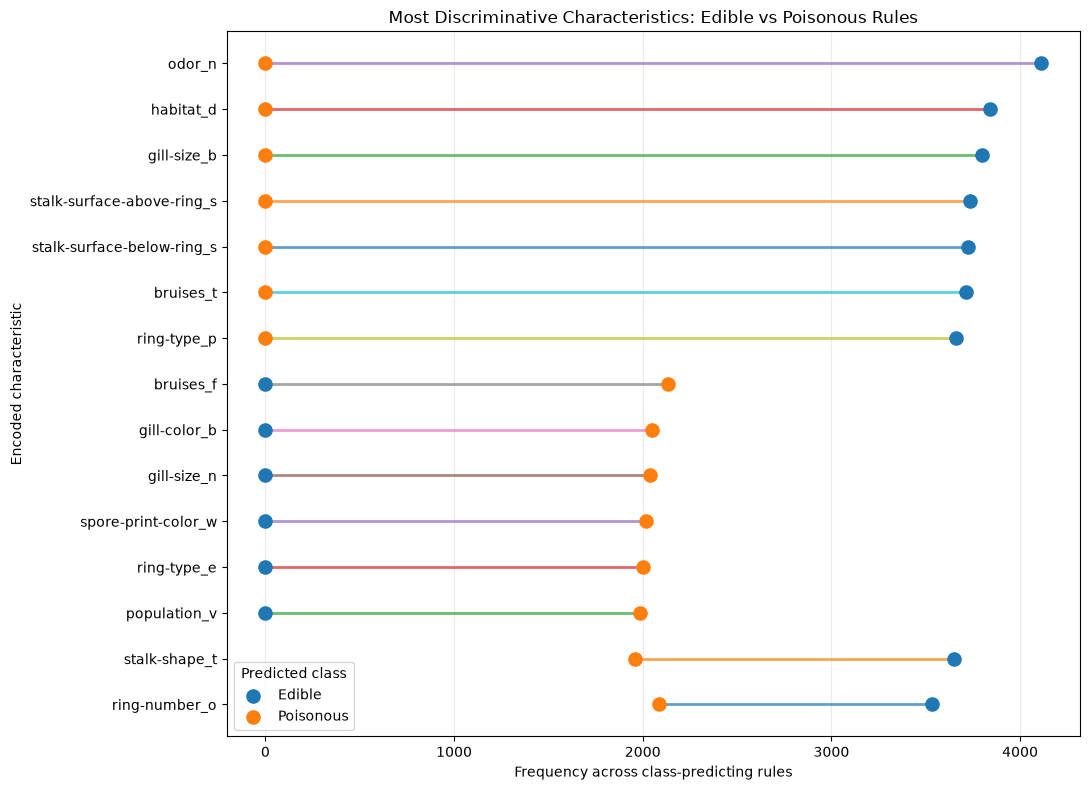

In [57]:
# Compare edible and poisonous rule frequencies

fig, ax = plt.subplots(figsize=(11, 8))

y_positions = np.arange(len(dumbbell_data))

for position, (_, row) in zip(
    y_positions,
    dumbbell_data.iterrows(),
):
    ax.plot(
        [
            row["frequency_edible"],
            row["frequency_poisonous"],
        ],
        [position, position],
        linewidth=2,
        alpha=0.7,
    )

ax.scatter(
    dumbbell_data["frequency_edible"],
    y_positions,
    s=90,
    label="Edible",
    zorder=3,
)

ax.scatter(
    dumbbell_data["frequency_poisonous"],
    y_positions,
    s=90,
    label="Poisonous",
    zorder=3,
)

ax.set_yticks(y_positions)
ax.set_yticklabels(dumbbell_data["characteristic"])

ax.set_xlabel("Frequency across class-predicting rules")
ax.set_ylabel("Encoded characteristic")
ax.set_title(
    "Most Discriminative Characteristics: "
    "Edible vs Poisonous Rules"
)

ax.legend(title="Predicted class")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Interpretation

Each horizontal line connects the frequency of the same characteristic in edible and poisonous association rules.

A long distance between both points indicates that the characteristic appears much more frequently in one class than in the other and may therefore be more discriminative within the extracted rule set.

Characteristics with points close together appear frequently in both classes and are less informative when considered independently.

## What did I learn?

The dumbbell plot reveals not only which characteristics are frequent, but also which ones create the strongest contrast between edible and poisonous rule sets.

This distinction is more useful than analysing total frequency alone because a common characteristic may still have limited discriminative value if it appears equally often in both classes.

# Heatmap — Class-Associated Characteristics

## Objective

This heatmap compares the relative frequency of the most relevant mushroom characteristics in association rules predicting edible and poisonous mushrooms.

## Why are we doing this?

The grouped bar chart and dumbbell plot show absolute differences between classes. The heatmap provides a more compact overview and makes it easier to identify class-specific and shared characteristics.

## Expected outcome

Characteristics with a strong value in only one column may be more class-specific, while characteristics with similar values in both columns may be common but less discriminative.

In [58]:
# Prepare the most discriminative characteristics for the heatmap

heatmap_data = (
    feature_comparison
    .assign(
        absolute_difference=lambda df: df["difference"].abs()
    )
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .head(15)
    .set_index("characteristic")[
        [
            "frequency_edible",
            "frequency_poisonous",
        ]
    ]
    .rename(
        columns={
            "frequency_edible": "Edible",
            "frequency_poisonous": "Poisonous",
        }
    )
)

heatmap_data

,Edible,Poisonous
characteristic,,
odor_n,4112,0
habitat_d,3840,0
gill-size_b,3800,0
stalk-surface-above-ring_s,3734,0
stalk-surface-below-ring_s,3726,0
bruises_t,3712,0
ring-type_p,3658,0
bruises_f,0,2132
gill-color_b,0,2048


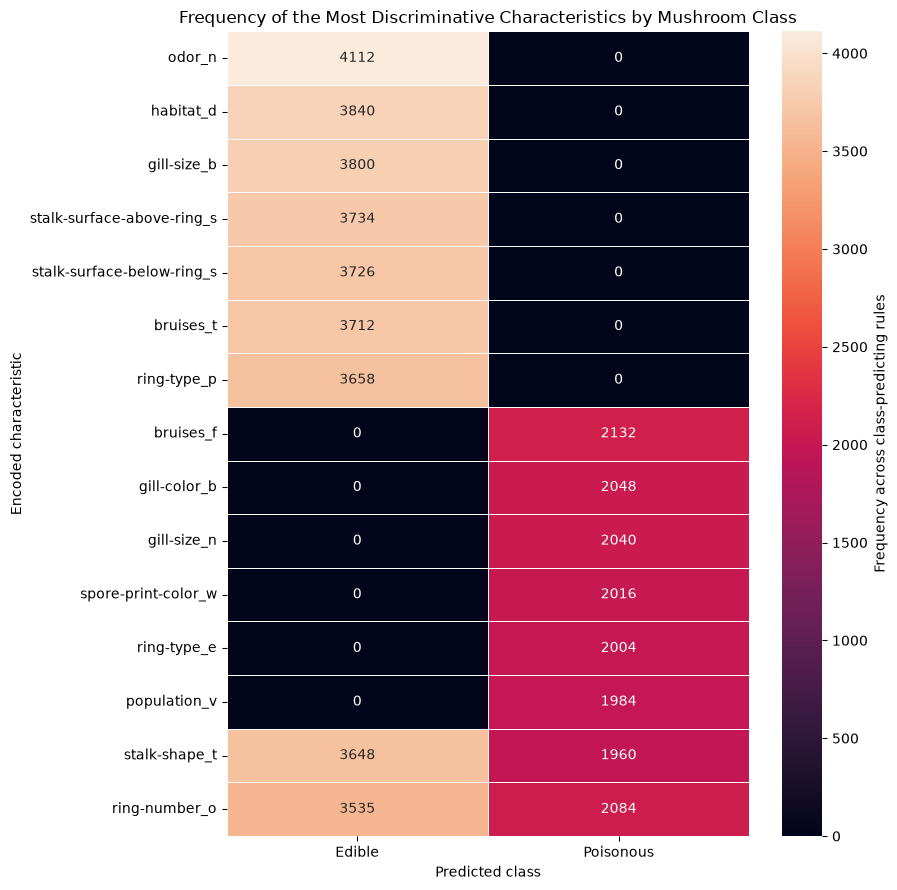

In [59]:
# Visualize class-associated characteristic frequencies

plt.figure(figsize=(9, 9))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={
        "label": "Frequency across class-predicting rules"
    },
)

plt.title(
    "Frequency of the Most Discriminative Characteristics "
    "by Mushroom Class"
)
plt.xlabel("Predicted class")
plt.ylabel("Encoded characteristic")

plt.tight_layout()
plt.show()

## Interpretation

The heatmap summarizes the characteristics with the largest frequency differences between edible and poisonous association rules.

Characteristics concentrated in the **Edible** column represent recurring patterns in rules predicting edible mushrooms. Characteristics concentrated in the **Poisonous** column represent patterns more strongly associated with poisonous outcomes.

The visualization also helps distinguish genuinely class-specific characteristics from variables that occur frequently in both classes.

Based on the current results:

- `odor_n` is strongly concentrated in edible rules.
- `bruises_t`, broad gills and specific stalk-surface characteristics are more strongly associated with edible outcomes.
- `bruises_f`, narrow gills, buff gill colour, white spore print and specific ring types are more strongly represented in poisonous rules.
- Characteristics appearing strongly in both columns are frequent within the dataset but may not be sufficient discriminators independently.

## What did I learn?

Different visualizations answer different questions.

The bar chart shows magnitude, the dumbbell plot emphasizes class differences, and the heatmap provides a compact pattern-level summary.

Together, these figures make it possible to move from thousands of individual association rules to a small number of interpretable findings about the dataset.

> These associations describe patterns in this academic dataset. They do not establish causality and must not be used as real-world guidance for determining whether a mushroom is safe to consume.

# Network Graph — Association Structure

## Objective

This network graph visualizes the strongest simple association rules connecting mushroom characteristics with edible and poisonous outcomes.

## Why are we doing this?

Tables and frequency charts summarize rule strength, but they do not show how characteristics connect to each class. A network representation makes these relationships explicit and helps identify shared and class-specific predictors.

## Expected outcome

A compact graph where encoded characteristics are connected to either the edible or poisonous class according to the selected high-confidence rules.

In [63]:
# Build a compact network from the strongest simple rules

import networkx as nx

network_rules = pd.concat(
    [
        poison_simple.assign(target="Poisonous"),
        edible_simple.assign(target="Edible"),
    ],
    ignore_index=True,
)

network_graph = nx.DiGraph()

for _, row in network_rules.iterrows():
    target = row["target"]

    network_graph.add_node(
        target,
        node_type="class",
    )

    for characteristic in row["antecedents"]:
        network_graph.add_node(
            characteristic,
            node_type="feature",
        )

        network_graph.add_edge(
            characteristic,
            target,
            weight=row["lift"],
        )

print(f"Network nodes: {network_graph.number_of_nodes()}")
print(f"Network edges: {network_graph.number_of_edges()}")

Network nodes: 17
Network edges: 18


In [62]:
from importlib.util import find_spec

print("networkx:", find_spec("networkx") is not None)
print("plotly:", find_spec("plotly") is not None)

networkx: True
plotly: True


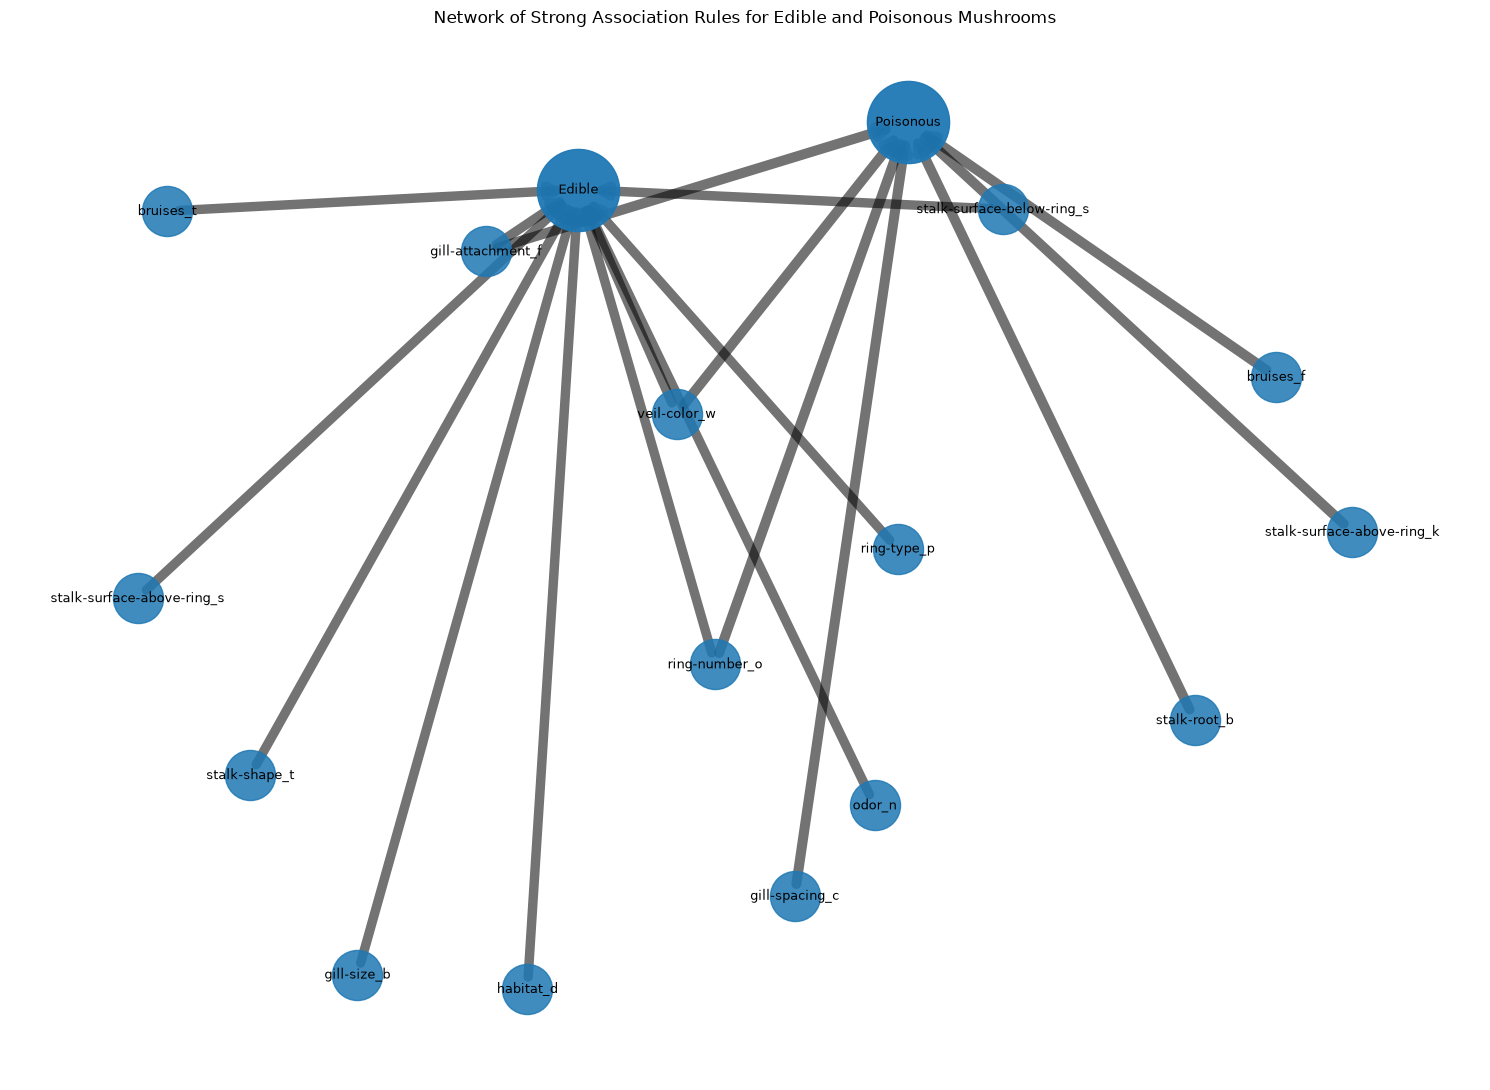

In [64]:
# Visualize feature-to-class associations

fig, ax = plt.subplots(figsize=(15, 11))

positions = nx.spring_layout(
    network_graph,
    seed=RANDOM_STATE,
    k=1.8,
    iterations=200,
)

class_nodes = [
    node
    for node, attributes in network_graph.nodes(data=True)
    if attributes["node_type"] == "class"
]

feature_nodes = [
    node
    for node, attributes in network_graph.nodes(data=True)
    if attributes["node_type"] == "feature"
]

edge_widths = [
    1 + network_graph[source][target]["weight"] * 3
    for source, target in network_graph.edges()
]

nx.draw_networkx_nodes(
    network_graph,
    positions,
    nodelist=feature_nodes,
    node_size=1300,
    alpha=0.85,
    ax=ax,
)

nx.draw_networkx_nodes(
    network_graph,
    positions,
    nodelist=class_nodes,
    node_size=3500,
    alpha=0.95,
    ax=ax,
)

nx.draw_networkx_edges(
    network_graph,
    positions,
    width=edge_widths,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=18,
    alpha=0.55,
    ax=ax,
)

nx.draw_networkx_labels(
    network_graph,
    positions,
    font_size=9,
    ax=ax,
)

ax.set_title(
    "Network of Strong Association Rules "
    "for Edible and Poisonous Mushrooms"
)
ax.axis("off")

plt.tight_layout()
plt.show()

## Interpretation

The graph represents encoded mushroom characteristics as feature nodes and the edible or poisonous outcomes as class nodes.

A feature connected only to one class appears more class-specific within the selected rule set. A feature connected to both classes participates in different combinations and should not be interpreted as a reliable standalone indicator.

The width of each connection reflects the accumulated support of the selected rules containing that feature-class relationship.

## What did I learn?

The network graph exposes the structure behind the association rules.

It shows that edible and poisonous outcomes are not linked to isolated characteristics alone, but to overlapping combinations of categorical attributes.

This visualization complements the frequency charts by showing connectivity rather than only magnitude.

> The graph represents statistical associations in this academic dataset. It does not establish causality or provide real-world mushroom identification guidance.

# Sankey Diagram — Characteristic-to-Class Flows

## Objective

This Sankey diagram summarizes the strongest characteristic-to-class relationships identified through Association Rule Mining.

## Why are we doing this?

The network graph emphasizes connectivity, while the Sankey diagram emphasizes the relative weight of each relationship.

Wider flows indicate characteristics with a greater accumulated presence across the selected association rules.

## Expected outcome

A compact visual summary showing which encoded mushroom characteristics contribute most strongly to edible and poisonous rule patterns.

In [65]:
# Prepare aggregated characteristic-to-class flows

sankey_rules = pd.concat(
    [
        edible_simple.assign(target="Edible"),
        poison_simple.assign(target="Poisonous"),
    ],
    ignore_index=True,
)

flow_records = []

for _, row in sankey_rules.iterrows():
    for characteristic in row["antecedents"]:
        flow_records.append(
            {
                "source": characteristic,
                "target": row["target"],
                "value": float(row["support"]),
            }
        )

sankey_flows = (
    pd.DataFrame(flow_records)
    .groupby(
        ["source", "target"],
        as_index=False,
    )["value"]
    .sum()
    .sort_values(
        "value",
        ascending=False,
    )
)

# Keep only the strongest flows so the diagram remains readable
sankey_flows = sankey_flows.head(18).copy()

sankey_flows

,source,target,value
13,stalk-surface-above-ring_k,Poisonous,2.713688
7,odor_n,Edible,2.387001
12,stalk-shape_t,Edible,2.280650
5,gill-spacing_c,Poisonous,1.634417
9,ring-number_o,Poisonous,1.349089
4,gill-size_b,Edible,0.638109
8,ring-number_o,Edible,0.638109
17,veil-color_w,Poisonous,0.544067
3,gill-attachment_f,Poisonous,0.541851
11,stalk-root_b,Poisonous,0.539636


In [66]:
# Visualize weighted flows from characteristics to class outcomes

import plotly.graph_objects as go

nodes = list(
    dict.fromkeys(
        sankey_flows["source"].tolist()
        + sankey_flows["target"].tolist()
    )
)

node_index = {
    node: index
    for index, node in enumerate(nodes)
}

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node={
                "label": nodes,
                "pad": 18,
                "thickness": 18,
                "line": {
                    "width": 0.5,
                },
            },
            link={
                "source": (
                    sankey_flows["source"]
                    .map(node_index)
                    .tolist()
                ),
                "target": (
                    sankey_flows["target"]
                    .map(node_index)
                    .tolist()
                ),
                "value": sankey_flows["value"].tolist(),
                "customdata": sankey_flows["value"].round(4),
                "hovertemplate": (
                    "%{source.label} → %{target.label}"
                    "<br>Accumulated support: %{customdata}"
                    "<extra></extra>"
                ),
            },
        )
    ]
)

fig.update_layout(
    title_text=(
        "Strong Association Flows toward "
        "Edible and Poisonous Mushroom Classes"
    ),
    font_size=11,
    height=720,
)

fig.show()

## Interpretation

The Sankey diagram represents the accumulated support of the strongest selected feature-to-class relationships.

Wider flows indicate that a characteristic appears repeatedly in high-support rules predicting the corresponding class.

The diagram should be interpreted together with the previous figures:

- The frequency chart measures repeated occurrence across the broader rule set.
- The dumbbell plot emphasizes differences between classes.
- The heatmap provides a compact class-level comparison.
- The network graph shows connectivity.
- The Sankey diagram highlights the relative weight of selected relationships.

Characteristics linked to both classes are not necessarily contradictory. Their meaning depends on the combinations in which they occur.

## What did I learn?

No single visualization fully represents the information contained in association rules.

The Sankey diagram is particularly useful for communicating the dominant flows from categorical characteristics to class outcomes, but it intentionally displays only a selected subset of rules to preserve readability.

> Flow width represents accumulated statistical support in the selected academic rule set. It does not represent causal influence or real-world mushroom safety.

# Knowledge Discovery

## From Patterns to Knowledge

The previous sections evaluated multiple unsupervised learning techniques from different perspectives.

Dimensionality reduction methods revealed the geometric organization of the dataset, clustering algorithms identified latent structures, and Association Rule Mining transformed categorical observations into explicit relationships.

Taken together, these techniques move the analysis beyond visualization or partitioning and allow meaningful knowledge to be extracted from the Mushroom dataset.

The following section summarizes the main findings obtained throughout the study.

## Geometric Structure of the Dataset

Both PCA and UMAP demonstrated that the Mushroom dataset possesses an underlying structure that separates edible and poisonous mushrooms.

PCA provided a linear projection that preserved the largest sources of variance while maintaining interpretability.

UMAP revealed a more fragmented manifold composed of compact local neighbourhoods that were not apparent in the linear projection.

Although the visual separation improved considerably, the embedding alone did not guarantee superior clustering performance.

This highlights an important principle in unsupervised learning:

> Better visualization does not necessarily imply better clustering.

## Clustering Insights

The clustering algorithms provided complementary views of the latent structure.

K-Means successfully recovered the dominant global organization of the dataset, producing moderate agreement with the reference labels.

HDBSCAN, instead, revealed numerous local density-based structures and identified observations that could not be confidently assigned to any cluster.

Increasing the minimum cluster size progressively merged neighbouring clusters while increasing the proportion of observations labelled as noise.

These results indicate that the Mushroom dataset is not organized as only two homogeneous groups, but rather contains several local substructures.

## Knowledge Discovery through Association Rules

Unlike clustering methods, Association Rule Mining does not attempt to partition observations.

Instead, it discovers explicit combinations of characteristics that repeatedly occur together.

The extracted rules revealed clear differences between edible and poisonous mushrooms.

The absence of odor (`odor_n`) emerged as the strongest recurring characteristic among edible mushrooms.

In contrast, poisonous mushrooms were associated with richer combinations involving bruising behaviour, gill morphology, ring type, spore-print colour and population.

These findings demonstrate that toxicity cannot be explained by a single characteristic but rather by interactions between multiple categorical attributes.

## Complementarity of the Methods

Each technique contributed different information.

PCA summarized the global variance.

UMAP revealed local manifold structure.

K-Means partitioned the observations into global groups.

HDBSCAN exposed density-based substructures.

Association Rules transformed statistical patterns into interpretable knowledge.

Rather than competing, these techniques complement one another by answering different analytical questions about the same dataset.

## Key Findings

> **Finding 1**
>
> The Mushroom dataset exhibits clear latent structure that can be recovered through dimensionality reduction.

---

> **Finding 2**
>
> UMAP improves visualization but does not necessarily improve clustering accuracy.

---

> **Finding 3**
>
> HDBSCAN identifies multiple local density structures that remain hidden under centroid-based clustering.

---

> **Finding 4**
>
> The absence of odor (`odor_n`) is the strongest recurring characteristic associated with edible mushrooms.

---

> **Finding 5**
>
> Poisonous mushrooms are characterized by combinations of several morphological features rather than by one dominant characteristic.

---

> **Finding 6**
>
> Association Rule Mining produced the most interpretable knowledge extracted from the dataset.

# Final Conclusions

This project explored several complementary unsupervised learning techniques using the Mushroom dataset.

The experiments demonstrated that different algorithms reveal different aspects of the same data.

Dimensionality reduction improved visual understanding, clustering uncovered latent structures, and Association Rule Mining transformed categorical observations into explicit and interpretable knowledge.

Together, these techniques illustrate that unsupervised learning is not limited to clustering, but also provides powerful tools for understanding complex datasets without relying on target labels.

The combination of visualization, clustering and rule mining offers a comprehensive analytical framework capable of revealing both statistical structure and domain knowledge.

Future work could extend this study using graph-based clustering, representation learning or topological data analysis to further investigate the geometry of high-dimensional categorical datasets.